<a href="https://colab.research.google.com/github/srilakshmi-saladi/NLP/blob/main/Drgrading_clinical_assessment_nlp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip -q install timm evaluate albumentations scikit-learn google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [7]:
import os
import random
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

import albumentations as A
from albumentations.pytorch import ToTensorV2

from google import genai
from google.colab import userdata

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
# Option 1: store GEMINI_API_KEY in Colab Secrets
# Left panel -> Secrets -> add GEMINI_API_KEY

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

# Option 2: if needed, manually uncomment and paste
# GEMINI_API_KEY = "YOUR_GEMINI_API_KEY"

client = genai.Client(api_key=GEMINI_API_KEY)
print("Gemini client initialized")

Gemini client initialized


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Change this to your actual dataset path in Drive/Colab
ROOT_DIR = Path("/content/drive/MyDrive/aptos")
CSV_PATH = ROOT_DIR / "train.csv"
IMG_DIR = ROOT_DIR / "train_images"

assert CSV_PATH.exists(), f"Missing CSV: {CSV_PATH}"
assert IMG_DIR.exists(), f"Missing image directory: {IMG_DIR}"

df = pd.read_csv(CSV_PATH)
print(df.head())
print("Total rows in CSV:", len(df))

df["image_path"] = df["id_code"].apply(lambda x: IMG_DIR / f"{x}.png")
df["exists"] = df["image_path"].apply(lambda p: Path(p).exists())
df = df[df["exists"]].copy().reset_index(drop=True)

print("Usable image-label pairs:", len(df))
print(df["diagnosis"].value_counts().sort_index())

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
Total rows in CSV: 3662
Usable image-label pairs: 2329
diagnosis
0    1377
1     201
2     510
3      90
4     151
Name: count, dtype: int64


In [36]:
!(ls -F '/content/drive')

MyDrive/  Shareddrives/


In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["diagnosis"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["diagnosis"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nTrain distribution:\n", train_df["diagnosis"].value_counts().sort_index())
print("\nVal distribution:\n", val_df["diagnosis"].value_counts().sort_index())
print("\nTest distribution:\n", test_df["diagnosis"].value_counts().sort_index())

Train: 1630
Val  : 349
Test : 350

Train distribution:
 diagnosis
0    964
1    140
2    357
3     63
4    106
Name: count, dtype: int64

Val distribution:
 diagnosis
0    206
1     30
2     76
3     14
4     23
Name: count, dtype: int64

Test distribution:
 diagnosis
0    207
1     31
2     77
3     13
4     22
Name: count, dtype: int64


In [13]:
IMG_SIZE = 256
BATCH_SIZE = 16
NUM_CLASSES = 5
EPOCHS = 15
LR = 1e-4

In [14]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.4
    ),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

valid_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [15]:
class APTOSDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = np.array(Image.open(row["image_path"]).convert("RGB"))
        label = int(row["diagnosis"])

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        return image, label

In [16]:
train_ds = APTOSDataset(train_df, transform=train_transform)
val_ds = APTOSDataset(val_df, transform=valid_transform)
test_ds = APTOSDataset(test_df, transform=valid_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print("Dataloaders ready")

Dataloaders ready


In [17]:
class DRClassifier(nn.Module):
    def __init__(self, num_classes: int = 5, dropout: float = 0.4):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

vision_model = DRClassifier(num_classes=NUM_CLASSES).to(device)
vision_model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

DRClassifier(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (bn1): BatchNormAct2d(
            40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw)

In [18]:
train_labels = train_df["diagnosis"].tolist()

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(vision_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

print("Class weights:", class_weights)

Class weights: tensor([0.3382, 2.3286, 0.9132, 5.1746, 3.0755], device='cuda:0')


In [19]:
def evaluate_classifier(model, loader, criterion):
    model.eval()
    losses = []
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)

            losses.append(loss.item())
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    loss_avg = float(np.mean(losses))
    acc = accuracy_score(y_true, y_pred)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    return loss_avg, acc, qwk, np.array(y_true), np.array(y_pred)

In [20]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_qwk": [],
}

best_val_qwk = -1.0
best_model_path = "/content/best_vision_model.pth"

for epoch in range(EPOCHS):
    vision_model.train()
    train_losses = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = vision_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_loss, val_acc, val_qwk, _, _ = evaluate_classifier(
        vision_model, val_loader, criterion
    )
    scheduler.step(val_qwk)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_qwk"].append(val_qwk)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val QWK: {val_qwk:.4f}"
    )

    if val_qwk > best_val_qwk:
        best_val_qwk = val_qwk
        torch.save(vision_model.state_dict(), best_model_path)
        print("Saved best vision model")

Epoch 1/15 | Train Loss: 1.4794 | Val Loss: 1.2948 | Val Acc: 0.7679 | Val QWK: 0.7540
Saved best vision model
Epoch 2/15 | Train Loss: 1.2384 | Val Loss: 1.1670 | Val Acc: 0.7765 | Val QWK: 0.7608
Saved best vision model
Epoch 3/15 | Train Loss: 1.1222 | Val Loss: 0.9524 | Val Acc: 0.7249 | Val QWK: 0.8123
Saved best vision model
Epoch 4/15 | Train Loss: 0.9430 | Val Loss: 0.8959 | Val Acc: 0.7966 | Val QWK: 0.8584
Saved best vision model
Epoch 5/15 | Train Loss: 0.8716 | Val Loss: 0.8690 | Val Acc: 0.7994 | Val QWK: 0.8549
Epoch 6/15 | Train Loss: 0.8003 | Val Loss: 0.8105 | Val Acc: 0.8166 | Val QWK: 0.8780
Saved best vision model
Epoch 7/15 | Train Loss: 0.7325 | Val Loss: 0.7910 | Val Acc: 0.8080 | Val QWK: 0.8650
Epoch 8/15 | Train Loss: 0.6745 | Val Loss: 0.7991 | Val Acc: 0.8109 | Val QWK: 0.8605
Epoch 9/15 | Train Loss: 0.5902 | Val Loss: 0.8779 | Val Acc: 0.8223 | Val QWK: 0.8821
Saved best vision model
Epoch 10/15 | Train Loss: 0.5496 | Val Loss: 0.9282 | Val Acc: 0.8138 | V

In [21]:
vision_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_acc, test_qwk, y_true, y_pred = evaluate_classifier(
    vision_model, test_loader, criterion
)

print("===== TEST RESULTS =====")
print("Loss     :", round(test_loss, 4))
print("Accuracy :", round(test_acc, 4))
print("QWK      :", round(test_qwk, 4))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

===== TEST RESULTS =====
Loss     : 1.0799
Accuracy : 0.8086
QWK      : 0.8971

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       207
           1       0.39      0.65      0.49        31
           2       0.76      0.58      0.66        77
           3       0.44      0.54      0.48        13
           4       0.58      0.50      0.54        22

    accuracy                           0.81       350
   macro avg       0.63      0.65      0.63       350
weighted avg       0.83      0.81      0.81       350



In [22]:
DR_GRADE_MAP = {
    0: {
        "label": "No DR",
        "finding": "No diabetic retinopathy detected",
    },
    1: {
        "label": "Mild NPDR",
        "finding": "Mild non-proliferative diabetic retinopathy with microaneurysms",
    },
    2: {
        "label": "Moderate DR",
        "finding": "Moderate diabetic retinopathy with increased retinal lesions",
    },
    3: {
        "label": "Severe DR",
        "finding": "Severe diabetic retinopathy with extensive vascular abnormalities",
    },
    4: {
        "label": "Proliferative DR",
        "finding": "Proliferative diabetic retinopathy with advanced retinal damage",
    },
}

In [23]:
inference_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [24]:
def generate_dynamic_report_with_gemini(
    pred_grade: int,
    grade_label: str,
    probs: np.ndarray,
    finding: str
) -> str:
    confidence = float(np.max(probs))
    confidence_pct = round(confidence * 100, 2)

    if confidence < 0.60:
        uncertainty_line = "Model confidence is relatively low, so the output should be interpreted cautiously."
    elif confidence < 0.80:
        uncertainty_line = "Model confidence is moderate, so clinical correlation is recommended."
    else:
        uncertainty_line = "Model confidence is relatively strong for this predicted class."

    prompt = f"""
You are assisting in a research demo for automated diabetic retinopathy screening.

Generate a brief clinical-style summary based only on these structured model outputs.

Inputs:
- Predicted DR grade: {pred_grade}
- Grade label: {grade_label}
- Model confidence: {confidence_pct}%
- Structured finding summary: {finding}
- Confidence note: {uncertainty_line}

Instructions:
1. Write 4 to 6 sentences.
2. Use cautious medical wording such as "suggestive of", "may indicate", or "consistent with".
3. Do not say the condition is definitively confirmed.
4. Mention follow-up recommendation.
5. If grade is 3 or 4, mention urgent ophthalmology evaluation.
6. Keep the language professional and concise.
7. Do not mention AI, language model, or prompt.
"""

    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt,
        )
        return response.text.strip()
    except Exception as e:
        return f"Report generation failed: {str(e)}"

In [25]:
def predict_and_generate_report(image_path: str) -> Dict:
    vision_model.eval()

    image = np.array(Image.open(image_path).convert("RGB"))
    tensor = inference_transform(image=image)["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = vision_model(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_grade = int(np.argmax(probs))

    grade_label = DR_GRADE_MAP[pred_grade]["label"]
    finding = DR_GRADE_MAP[pred_grade]["finding"]

    report = generate_dynamic_report_with_gemini(
        pred_grade=pred_grade,
        grade_label=grade_label,
        probs=probs,
        finding=finding,
    )

    return {
        "predicted_grade": pred_grade,
        "grade_label": grade_label,
        "probabilities": probs,
        "generated_report": report,
    }

In [26]:
print("Vision model test accuracy:", round(test_acc, 4))
print("Vision model test QWK     :", round(test_qwk, 4))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

Vision model test accuracy: 0.8086
Vision model test QWK     : 0.8971

Confusion Matrix:
 [[200   7   0   0   0]
 [  4  20   7   0   0]
 [  1  23  45   4   4]
 [  0   0   2   7   4]
 [  0   1   5   5  11]]


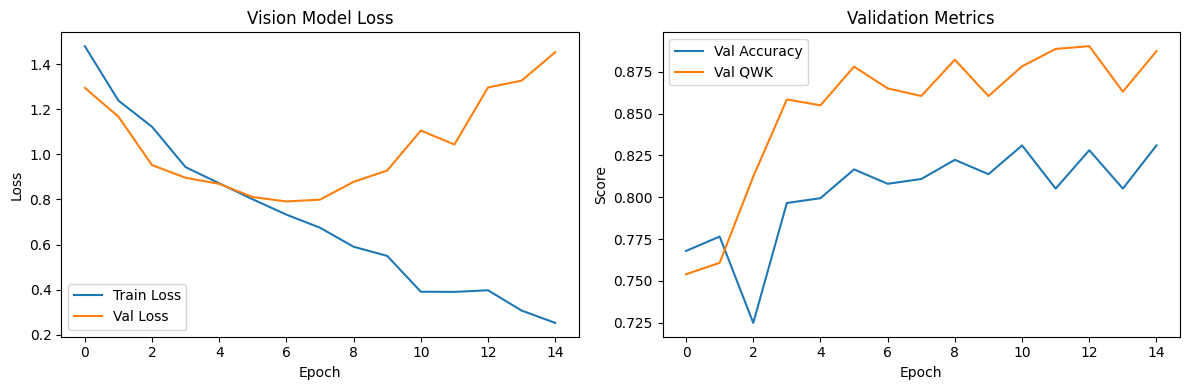

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Vision Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label="Val Accuracy")
plt.plot(history["val_qwk"], label="Val QWK")
plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
sample_indices = np.random.choice(len(test_df), size=min(5, len(test_df)), replace=False)

for idx in sample_indices:
    row = test_df.iloc[idx]
    result = predict_and_generate_report(str(row["image_path"]))

    print("=" * 100)
    print("Image:", row["image_path"])
    print("True Grade:", row["diagnosis"])
    print("Pred Grade:", result["predicted_grade"], "-", result["grade_label"])
    print("Probabilities:", np.round(result["probabilities"], 4))
    print("\nGenerated Clinical Summary:")
    print(result["generated_report"])

Image: /content/drive/MyDrive/aptos/train_images/5a03fe3ed15c.png
True Grade: 2
Pred Grade: 4 - Proliferative DR
Probabilities: [0.0014 0.0572 0.4277 0.0603 0.4535]

Generated Clinical Summary:
The automated screening system suggests findings consistent with Proliferative Diabetic Retinopathy. Advanced retinal damage may be present. Given the relatively low model confidence (45.35%), these findings should be interpreted with caution. An urgent ophthalmology evaluation is recommended for definitive diagnosis and management. Close ophthalmologic follow-up is essential.
Image: /content/drive/MyDrive/aptos/train_images/69fff98cb32a.png
True Grade: 4
Pred Grade: 4 - Proliferative DR
Probabilities: [0.00e+00 9.00e-04 5.90e-03 1.71e-02 9.76e-01]

Generated Clinical Summary:
The screening results are highly suggestive of Proliferative Diabetic Retinopathy (PDR), corresponding to a predicted grade of 4. This finding may indicate advanced retinal damage. The confidence for this predicted classif

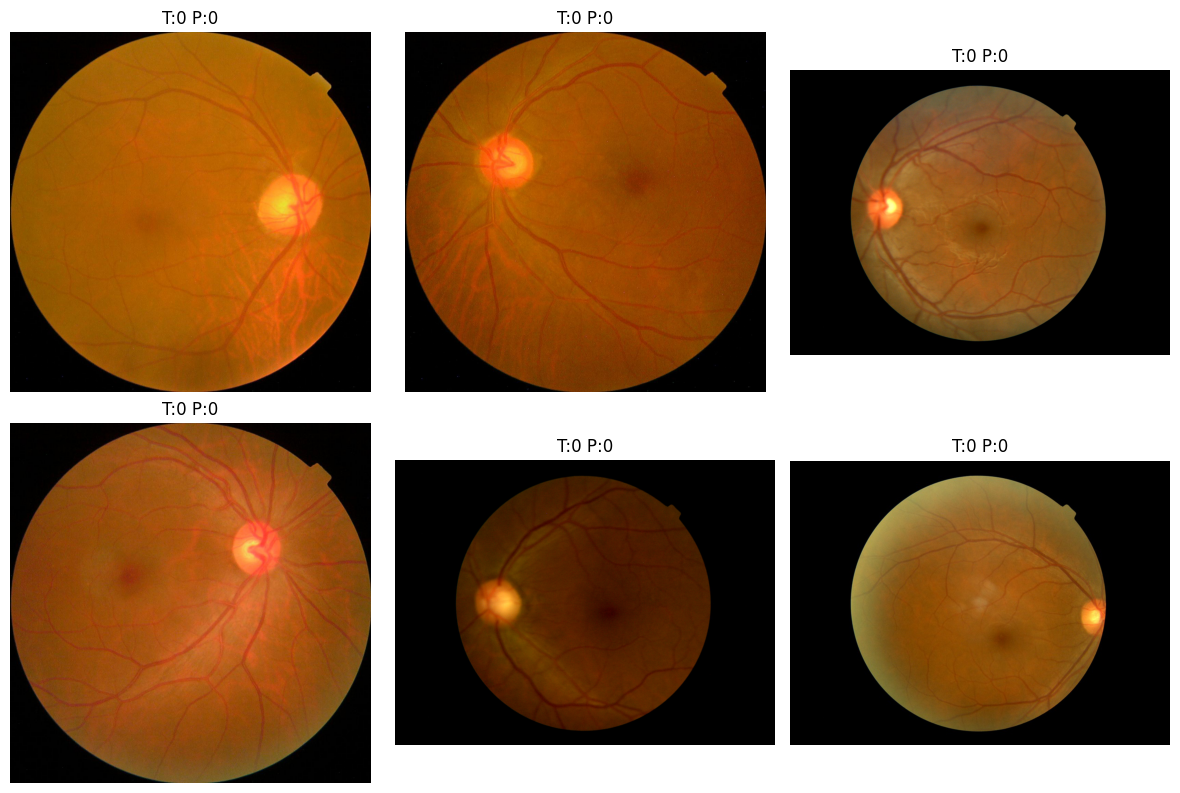

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

sample_indices = np.random.choice(len(test_df), size=min(6, len(test_df)), replace=False)

for ax, idx in zip(axes, sample_indices):
    row = test_df.iloc[idx]
    result = predict_and_generate_report(str(row["image_path"]))
    img = Image.open(row["image_path"]).convert("RGB")

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"T:{row['diagnosis']} P:{result['predicted_grade']}")

plt.tight_layout()
plt.show()

In [30]:
!pip -q install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [41]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam_target_layers = [vision_model.backbone.blocks[-1]]
cam = GradCAM(model=vision_model, target_layers=cam_target_layers)

In [43]:
from typing import Optional
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def plot_gradcam(image_path: str, save_dir: Optional[str] = None, display_plot: bool = True):
    rgb = np.array(Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    rgb_float = rgb.astype(np.float32) / 255.0
    tensor = inference_transform(image=rgb)["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = vision_model(tensor)
        pred_class = int(torch.argmax(logits, dim=1).item())

    grayscale_cam = cam(
        input_tensor=tensor,
        targets=[ClassifierOutputTarget(pred_class)]
    )[0]

    cam_image = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(cam_image)
    axes[1].set_title(f"Grad-CAM (Pred Grade: {pred_class})")
    axes[1].axis("off")

    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, f"gradcam_{Path(image_path).name}"))
        plt.close(fig) # Close the figure to free memory after saving
    if display_plot:
        plt.show()


Saving fe5618ad2460.png to fe5618ad2460.png
Uploaded image: fe5618ad2460.png
Predicted DR Grade: 2 - Moderate DR
Probabilities: [0.0013 0.0211 0.9093 0.0456 0.0226]

Generated Clinical Summary:
The automated screening system detected findings suggestive of moderate diabetic retinopathy (Grade 2), with a confidence level of 90.93%. Specifically, the analysis indicates the presence of increased retinal lesions consistent with this grade. These are AI-generated screening observations and should not be interpreted as a definitive medical diagnosis. Clinical correlation and comprehensive ophthalmic evaluation are recommended for confirmation and to establish an appropriate management plan.


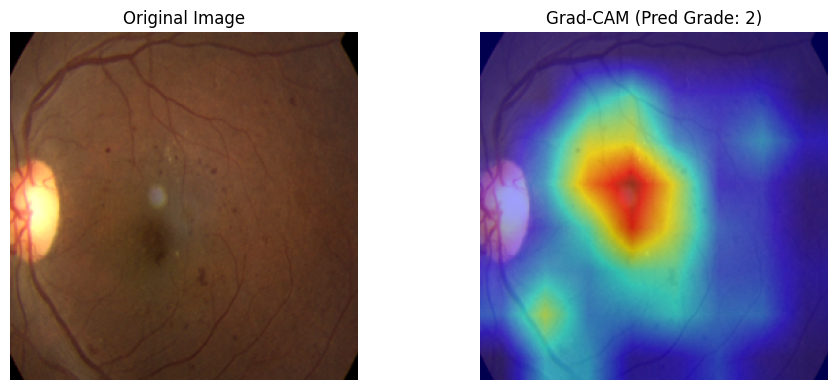

In [44]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    result = predict_and_generate_report(filename)

    print("Uploaded image:", filename)
    print("Predicted DR Grade:", result["predicted_grade"], "-", result["grade_label"])
    print("Probabilities:", np.round(result["probabilities"], 4))
    print("\nGenerated Clinical Summary:")
    print(result["generated_report"])

    plot_gradcam(filename, display_plot=True) # Ensure display for single upload


In [45]:
output_dir = Path("/content/dr_reports")
output_dir.mkdir(parents=True, exist_ok=True)

reports_data = []

# You can adjust the number of samples as needed
sample_indices = np.random.choice(len(test_df), size=min(len(test_df), 10), replace=False)

print(f"Generating reports and Grad-CAMs for {len(sample_indices)} test images...")

for idx in sample_indices:
    row = test_df.iloc[idx]
    image_path = str(row["image_path"])
    true_grade = row["diagnosis"]

    # Generate prediction and report
    result = predict_and_generate_report(image_path)

    # Generate and save Grad-CAM
    plot_gradcam(image_path, save_dir=str(output_dir), display_plot=False)

    reports_data.append({
        "image_id": Path(image_path).stem,
        "image_path": image_path,
        "true_grade": true_grade,
        "predicted_grade": result["predicted_grade"],
        "grade_label": result["grade_label"],
        "probabilities": str(np.round(result["probabilities"], 4).tolist()),
        "generated_report": result["generated_report"],
        "gradcam_path": str(output_dir / f"gradcam_{Path(image_path).name}")
    })
    print(f"Processed image: {Path(image_path).name}")

reports_df = pd.DataFrame(reports_data)
reports_csv_path = output_dir / "dr_clinical_reports.csv"
reports_df.to_csv(reports_csv_path, index=False)

print("\n--- Report Generation Complete ---")
print(f"Generated {len(reports_df)} clinical reports saved to: {reports_csv_path}")
print(f"Generated {len(reports_df)} Grad-CAM images saved to: {output_dir}")
print("Here's a preview of the saved reports:")
print(reports_df.head())


Generating reports and Grad-CAMs for 10 test images...
Processed image: bf9cba745efc.png
Processed image: 387138ddf43d.png
Processed image: a85cda5f725d.png
Processed image: b574d229ec4c.png
Processed image: 5a03fe3ed15c.png
Processed image: 70d0392397de.png
Processed image: 42c65af5ab16.png
Processed image: e12d41e7b221.png
Processed image: 875d2ffcbf47.png
Processed image: 8ead17dfb6a6.png

--- Report Generation Complete ---
Generated 10 clinical reports saved to: /content/dr_reports/dr_clinical_reports.csv
Generated 10 Grad-CAM images saved to: /content/dr_reports
Here's a preview of the saved reports:
       image_id                                         image_path  \
0  bf9cba745efc  /content/drive/MyDrive/aptos/train_images/bf9c...   
1  387138ddf43d  /content/drive/MyDrive/aptos/train_images/3871...   
2  a85cda5f725d  /content/drive/MyDrive/aptos/train_images/a85c...   
3  b574d229ec4c  /content/drive/MyDrive/aptos/train_images/b574...   
4  5a03fe3ed15c  /content/drive/MyDri

In [46]:
FINAL_VISION_PATH = "/content/final_vision_model.pth"

vision_model.load_state_dict(torch.load(best_model_path, map_location=device))
torch.save(vision_model.state_dict(), FINAL_VISION_PATH)

print("Saved vision model to:", FINAL_VISION_PATH)

Saved vision model to: /content/final_vision_model.pth


In [47]:
def generate_dynamic_report_with_gemini(
    pred_grade: int,
    grade_label: str,
    probs: np.ndarray,
    finding: str
) -> str:
    confidence = float(np.max(probs))
    confidence_pct = round(confidence * 100, 2)

    prompt = f"""
You are assisting in a research demo for diabetic retinopathy screening.

Write a short, cautious, clinical-style summary from these structured outputs:

- Predicted grade: {pred_grade}
- Grade label: {grade_label}
- Confidence: {confidence_pct}%
- Finding summary: {finding}

Requirements:
- 3 to 5 sentences
- Use cautious wording
- Do not claim definitive diagnosis
- Mention recommended follow-up
- If severe or proliferative, recommend urgent specialist evaluation
"""
    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt,
        )
        return response.text.strip()
    except Exception as e:
        return f"Report generation failed: {str(e)}"